# 🐦 Getting Started with Acoustic Data for Ecologists
## An Australian Perspective

---

This notebook provides a complete, reproducible workflow for ecologists working with bioacoustic data in Australia.  
It walks through five stages:

| # | Stage | What you'll learn |
|---|-------|-------------------|
| 0 | **Configuration** | How to swap data sources without changing the workflow |
| 1 | **Data Acquisition** | Fetching open bird-call recordings from Xeno-canto via GBIF |
| 2 | **Quality Checks** | Validating audio files before analysis |
| 3 | **Visualisation** | Waveforms, spectrograms, and mel-spectrograms |
| 4 | **Sound Classification** | Identifying species with BirdNET (pre-trained CNN) |
| 5 | **Occurrence Export** | Turning detections into species × location records (CSV) |

**Data source:** [Xeno-canto](https://xeno-canto.org) via [GBIF](https://www.gbif.org) (open access, CC licensed).  
**Reference frameworks:** [bird-recognition-review](https://github.com/AgaMiko/bird-recognition-review) · [BirdSet](https://huggingface.co/datasets/DBD-research-group/BirdSet)  
**Example species:** from Robson Creek, Wet Tropics QLD — *Edolisoma tenuirostre* (Common Cicadabird) and *Melithreptus albogularis* (White-throated Honeyeater).

> **Swap your own data:** Edit only **Section 0**. Sections 1–5 run identically regardless of where the audio comes from.


## 📦 Install Dependencies

Run this cell once. All packages are fetched from PyPI — nothing is bundled in this repo.

In [1]:
# Run once to install required packages
import sys
!{sys.executable} -m pip install -q \
    librosa soundfile matplotlib pandas requests numpy birdnetlib

---
## Section 0 — Configuration ✏️

> **This is the only section you need to edit when swapping data sources.**  
> Change `DATA_SOURCE` and the relevant block below. Everything else stays the same.

### Supported data sources
| `DATA_SOURCE` value | What it does |
|---|---|
| `"xeno-canto-gbif"` | Fetches recordings from Xeno-canto via GBIF API (default) |
| `"local"` | Uses WAV files you already have on disk (e.g. from Acoustic Observatory) |


In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  SECTION 0 — DATA SOURCE CONFIGURATION                         ║
# ║  ► Edit ONLY this cell to use your own data.                   ║
# ║  ► Sections 1–5 run identically for all data sources.          ║
# ╚══════════════════════════════════════════════════════════════════╝

from pathlib import Path

# ── Choose data source ───────────────────────────────────────────────
DATA_SOURCE = "xeno-canto-gbif"   # "xeno-canto-gbif" | "local"


# ── Xeno-canto via GBIF ─────────────────────────────────────────────
# Used when DATA_SOURCE = "xeno-canto-gbif"

GBIF_DATASET_KEY = "b1047888-ae52-4179-9dd5-5448ea342a24"  # Xeno-canto dataset on GBIF

# Species of interest — scientific names (edit this list for your study)
TARGET_SPECIES = [
    "Edolisoma tenuirostre",    # Common Cicadabird
    "Melithreptus albogularis", # White-throated Honeyeater
]

COUNTRY_CODE    = "AU"        # ISO 3166-1 alpha-2
MAX_PER_SPECIES = 5           # Max recordings to fetch per species


# ── Local data (your own WAV files) ─────────────────────────────────
# Used when DATA_SOURCE = "local"
# Your metadata CSV must have columns:
#   recording_id, species, common_name, lat, lon, audio_path, date
LOCAL_AUDIO_DIR    = Path("audio_data")
LOCAL_METADATA_CSV = Path("metadata.csv")


# ── Output directories (shared) ──────────────────────────────────────
AUDIO_DIR   = Path("audio_data")
RESULTS_DIR = Path("results")
AUDIO_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)


# ── BirdNET classifier settings ──────────────────────────────────────
MIN_CONFIDENCE        = 0.25   # Min detection confidence for BirdNET (0–1)
OCCURRENCE_CONFIDENCE = 0.50   # Min confidence to include in occurrence CSV

print("Configuration loaded.")
print(f"  Data source    : {DATA_SOURCE}")
print(f"  Target species : {TARGET_SPECIES}")
print(f"  Country        : {COUNTRY_CODE}")
print(f"  Audio dir      : {AUDIO_DIR.resolve()}")
print(f"  Results dir    : {RESULTS_DIR.resolve()}")

Configuration loaded.
  Data source    : xeno-canto-gbif
  Target species : ['Edolisoma tenuirostre', 'Melithreptus albogularis']
  Country        : AU
  Audio dir      : /Users/ecocommons/Downloads/GIT_Repo/acoustic_model/audio_data
  Results dir    : /Users/ecocommons/Downloads/GIT_Repo/acoustic_model/results


In [3]:
# Standard imports — do not edit
import time
import warnings
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import librosa
import librosa.display
from datetime import datetime

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_colwidth", 60)
print("Imports OK")

Imports OK


---
## Section 1 — Data Acquisition 🌐

We pull bird-call recordings from **Xeno-canto via the GBIF Occurrence API**.  
GBIF hosts Xeno-canto as a citable, versioned dataset (CC BY-NC-SA 4.0).  
Each record comes with:
- A direct **WAV audio URL** hosted on xeno-canto.org
- **Decimal lat/lon** of where the bird was recorded
- Taxonomic metadata, recording date, and recorder name

> **GBIF dataset:** https://www.gbif.org/dataset/b1047888-ae52-4179-9dd5-5448ea342a24  
> **API docs:** https://www.gbif.org/developer/occurrence

In [4]:
def fetch_xeno_canto_gbif(species_list, country, dataset_key, max_per_species=5):
    """
    Query GBIF for Xeno-canto sound recordings.

    Parameters
    ----------
    species_list     : list of scientific names
    country          : ISO 3166-1 alpha-2 country code (e.g. 'AU')
    dataset_key      : GBIF dataset UUID for Xeno-canto
    max_per_species  : max records to return per species

    Returns
    -------
    pd.DataFrame with columns:
      recording_id, species, common_name, lat, lon, date,
      country, locality, recorded_by, license, audio_url, audio_path
    """
    base_url = "https://api.gbif.org/v1/occurrence/search"
    records  = []

    for sp in species_list:
        print(f"  Querying GBIF for {sp} ...", end=" ")
        params = {
            "datasetKey"    : dataset_key,
            "scientificName": sp,
            "country"       : country,
            "mediaType"     : "Sound",
            "limit"         : max_per_species,
        }
        try:
            r = requests.get(base_url, params=params, timeout=20)
            r.raise_for_status()
        except Exception as e:
            print(f"FAILED ({e})")
            continue

        data  = r.json()
        total = data.get("count", 0)
        print(f"{total} records on GBIF — fetching {min(max_per_species, total)}")

        for occ in data.get("results", []):
            # Pull the first Sound URL from the media array
            audio_url = next(
                (m["identifier"] for m in occ.get("media", [])
                 if m.get("type") == "Sound"),
                None,
            )
            if not audio_url:
                continue

            records.append({
                "recording_id" : occ.get("occurrenceID", "").split("/")[-1],
                "species"      : occ.get("species", sp),
                "common_name"  : occ.get("vernacularName", ""),
                "lat"          : occ.get("decimalLatitude"),
                "lon"          : occ.get("decimalLongitude"),
                "date"         : occ.get("eventDate"),
                "country"      : occ.get("country", country),
                "locality"     : occ.get("locality", ""),
                "recorded_by"  : occ.get("recordedBy", ""),
                "license"      : occ.get("license", ""),
                "audio_url"    : audio_url,
                "audio_path"   : None,
            })

        time.sleep(0.5)   # polite rate-limiting

    df = pd.DataFrame(records)
    print(f"\nTotal records fetched: {len(df)}")
    return df


def download_audio_files(df, audio_dir):
    """
    Download audio files from URLs in df['audio_url'].
    Skips files already on disk.
    Adds 'audio_path' column with local file paths.
    """
    paths = []
    for _, row in df.iterrows():
        url  = row["audio_url"]
        ext  = Path(url).suffix or ".wav"
        fname = f"{row['recording_id']}{ext}"
        dest  = Path(audio_dir) / fname

        if dest.exists():
            print(f"  [skip] {fname} already downloaded")
            paths.append(dest)
            continue

        print(f"  [download] {fname} ...", end=" ")
        try:
            resp = requests.get(url, timeout=60, stream=True)
            resp.raise_for_status()
            with open(dest, "wb") as f:
                for chunk in resp.iter_content(1 << 20):
                    f.write(chunk)
            size_kb = dest.stat().st_size // 1024
            print(f"✓  ({size_kb} KB)")
            paths.append(dest)
        except Exception as e:
            print(f"✗  {e}")
            paths.append(None)

    df = df.copy()
    df["audio_path"] = paths
    return df


def load_local_data(audio_dir, metadata_csv):
    """
    Load pre-existing audio + metadata from disk.
    metadata_csv must have: recording_id, species, common_name,
                            lat, lon, audio_path, date
    """
    df = pd.read_csv(metadata_csv)
    df["audio_path"] = df["audio_path"].apply(
        lambda p: Path(audio_dir) / p if not Path(p).is_absolute() else Path(p)
    )
    print(f"Loaded {len(df)} records from {metadata_csv}")
    return df

In [5]:
# ── Run data acquisition ─────────────────────────────────────────────
print(f"Data source: {DATA_SOURCE}\n")

if DATA_SOURCE == "xeno-canto-gbif":
    metadata_df = fetch_xeno_canto_gbif(
        TARGET_SPECIES, COUNTRY_CODE, GBIF_DATASET_KEY, MAX_PER_SPECIES
    )
    print("\nDownloading audio files...")
    metadata_df = download_audio_files(metadata_df, AUDIO_DIR)

elif DATA_SOURCE == "local":
    metadata_df = load_local_data(LOCAL_AUDIO_DIR, LOCAL_METADATA_CSV)

else:
    raise ValueError(f"Unknown DATA_SOURCE: {DATA_SOURCE!r}")

# Save metadata to disk
metadata_df.to_csv(RESULTS_DIR / "metadata.csv", index=False)
print(f"\nMetadata saved → {RESULTS_DIR / 'metadata.csv'}")
metadata_df.head(10)

Data source: xeno-canto-gbif

  Querying GBIF for Edolisoma tenuirostre ... 53 records on GBIF — fetching 5
  Querying GBIF for Melithreptus albogularis ... 96 records on GBIF — fetching 5

Total records fetched: 10

  [skip] XC1084935.mp3 already downloaded
  [skip] XC1084937.mp3 already downloaded
  [skip] XC1084936.mp3 already downloaded
  [skip] XC1084934.mp3 already downloaded
  [skip] XC1088936.mp3 already downloaded
  [skip] XC1086697.mp3 already downloaded
  [skip] XC1080953.mp3 already downloaded
  [skip] XC1066686.mp3 already downloaded
  [skip] XC935474.wav already downloaded
  [skip] XC822066.wav already downloaded

Metadata saved → results/metadata.csv


,recording_id,species,common_name,lat,lon,date,country,locality,recorded_by,license,audio_url,audio_path
0,XC1084935,Edolisoma tenuirostre,Common Cicadabird,-28.8460,152.0499,2026-02-21,Australia,"Bald Rock National Park, New South Wales",Marc Anderson,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/EHGWCIGILC/XC1084...,audio_data/XC1084935.mp3
1,XC1084937,Edolisoma tenuirostre,Common Cicadabird,-28.8460,152.0499,2026-02-21,Australia,"Bald Rock National Park, New South Wales",Marc Anderson,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/EHGWCIGILC/XC1084...,audio_data/XC1084937.mp3
2,XC1084936,Edolisoma tenuirostre,Common Cicadabird,-28.8460,152.0499,2026-02-21,Australia,"Bald Rock National Park, New South Wales",Marc Anderson,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/EHGWCIGILC/XC1084...,audio_data/XC1084936.mp3
3,XC1084934,Edolisoma tenuirostre,Common Cicadabird,-28.8460,152.0499,2026-02-21,Australia,"Bald Rock National Park, New South Wales",Marc Anderson,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/EHGWCIGILC/XC1084...,audio_data/XC1084934.mp3
4,XC1088936,Edolisoma tenuirostre,Common Cicadabird,-28.2004,153.1893,2025-02-23,Australia,"Binna Burra, Scenic Rim Regional, Queensland",Marc Anderson,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/EHGWCIGILC/XC1088...,audio_data/XC1088936.mp3
5,XC1086697,Melithreptus albogularis,White-throated Honeyeater,-29.6266,153.2959,2026-02-20,Australia,"Brooms Head, Clarence Valley Council, New South Wales",Marc Anderson,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/EHGWCIGILC/XC1086...,audio_data/XC1086697.mp3
6,XC1080953,Melithreptus albogularis,White-throated Honeyeater,-15.1972,144.4289,2025-10-30,Australia,"Twelve Mile Lagoon, Lakefield National Park, Queensland",Étienne Leroy,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/ZWAQHOJFLZ/XC1080...,audio_data/XC1080953.mp3
7,XC1066686,Melithreptus albogularis,White-throated Honeyeater,-28.2307,153.1359,2025-10-26,Australia,"Lamington National Park, Queensland",Peter Boesman,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/OOECIWCSWV/XC1066...,audio_data/XC1066686.mp3
8,XC935474,Melithreptus albogularis,White-throated Honeyeater,-27.8038,153.4284,2024-09-24,Australia,"South Stradbroke, City of Gold Coast, Queensland",Richard White,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/IQGZKQAMKT/XC9354...,audio_data/XC935474.wav
9,XC822066,Melithreptus albogularis,White-throated Honeyeater,-12.4422,130.9102,2023-08-04,Australia,"Hidden Valley, City of Darwin, Northern Territory",James Lambert,http://creativecommons.org/licenses/by-nc/4.0/legalcode,https://xeno-canto.org/sounds/uploaded/OHGEFOWNMD/XC8220...,audio_data/XC822066.wav


---
## Section 2 — Quality Checks ✅

Before analysis, we validate each audio file for:

| Check | Why it matters |
|-------|----------------|
| **File exists & is readable** | Catch failed downloads early |
| **Duration** | Very short clips (<1 s) may not classify reliably |
| **Sample rate** | BirdNET expects ≥ 22 050 Hz; librosa can resample |
| **File size** | Zero-byte files indicate a download error |
| **SNR estimate** | Low signal-to-noise = dominated by wind/rain noise |

Files that fail checks are flagged but kept — you decide whether to exclude them.

In [6]:
def estimate_snr_db(y):
    """
    Simple SNR proxy: ratio of mean RMS to the 10th-percentile RMS frame.
    Higher = cleaner signal. Values below ~3 dB indicate very noisy recordings.
    """
    rms         = librosa.feature.rms(y=y)[0]
    noise_floor = np.percentile(rms, 10)
    signal_rms  = np.mean(rms)
    if noise_floor > 0:
        return round(20 * np.log10(signal_rms / noise_floor), 1)
    return None


def check_audio_quality(row):
    """Run quality checks for a single recording row. Returns a dict."""
    result = {
        "recording_id" : row["recording_id"],
        "species"      : row["species"],
        "file"         : None,
        "exists"       : False,
        "file_size_kb" : None,
        "duration_s"   : None,
        "sample_rate"  : None,
        "snr_db"       : None,
        "status"       : "fail",
        "flag"         : "",
    }

    path = row.get("audio_path")
    if path is None:
        result["flag"] = "no path — download may have failed"
        return result

    path = Path(path)
    result["file"] = path.name

    if not path.exists():
        result["flag"] = "file missing on disk"
        return result

    result["exists"]       = True
    result["file_size_kb"] = round(path.stat().st_size / 1024, 1)

    if result["file_size_kb"] < 1:
        result["flag"] = "zero-byte file"
        return result

    try:
        y, sr = librosa.load(str(path), sr=None, mono=True)
        result["sample_rate"] = sr
        result["duration_s"]  = round(len(y) / sr, 2)
        result["snr_db"]      = estimate_snr_db(y)
        result["status"]      = "ok"

        flags = []
        if result["duration_s"] < 1.0:
            flags.append("very short (<1 s)")
        if sr < 22050:
            flags.append(f"low sample rate ({sr} Hz)")
        if result["snr_db"] is not None and result["snr_db"] < 3:
            flags.append("low SNR (<3 dB)")
        result["flag"] = "; ".join(flags)

    except Exception as e:
        result["status"] = "error"
        result["flag"]   = str(e)

    return result

In [7]:
print("Running quality checks...\n")
qc_rows = [check_audio_quality(row) for _, row in metadata_df.iterrows()]
qc_df   = pd.DataFrame(qc_rows)

# Summary
n_ok   = (qc_df["status"] == "ok").sum()
n_fail = (qc_df["status"] != "ok").sum()
print(f"\nQuality check summary: {n_ok} OK  |  {n_fail} failed/flagged")
print(f"Duration range : {qc_df['duration_s'].min():.1f}s – {qc_df['duration_s'].max():.1f}s")
print(f"Sample rates   : {qc_df['sample_rate'].unique()}")
print(f"SNR range (dB) : {qc_df['snr_db'].min():.1f} – {qc_df['snr_db'].max():.1f}")

qc_df.to_csv(RESULTS_DIR / "quality_checks.csv", index=False)
print(f"\nQuality report saved → {RESULTS_DIR / 'quality_checks.csv'}")
qc_df

Running quality checks...


Quality check summary: 10 OK  |  0 failed/flagged
Duration range : 10.0s – 97.0s
Sample rates   : [48000 44100]
SNR range (dB) : 2.2 – 18.6

Quality report saved → results/quality_checks.csv


,recording_id,species,file,exists,file_size_kb,duration_s,sample_rate,snr_db,status,flag
0,XC1084935,Edolisoma tenuirostre,XC1084935.mp3,True,397.3,10.00,48000,8.3,ok,
1,XC1084937,Edolisoma tenuirostre,XC1084937.mp3,True,510.8,12.89,48000,10.6,ok,
2,XC1084936,Edolisoma tenuirostre,XC1084936.mp3,True,2929.5,74.82,48000,8.3,ok,
3,XC1084934,Edolisoma tenuirostre,XC1084934.mp3,True,948.6,24.10,48000,5.6,ok,
4,XC1088936,Edolisoma tenuirostre,XC1088936.mp3,True,962.7,24.47,48000,18.6,ok,
5,XC1086697,Melithreptus albogularis,XC1086697.mp3,True,3794.9,96.98,48000,11.4,ok,
6,XC1080953,Melithreptus albogularis,XC1080953.mp3,True,218.1,13.58,44100,8.5,ok,
7,XC1066686,Melithreptus albogularis,XC1066686.mp3,True,481.5,30.53,48000,12.1,ok,
8,XC935474,Melithreptus albogularis,XC935474.wav,True,4373.7,23.33,48000,5.2,ok,
9,XC822066,Melithreptus albogularis,XC822066.wav,True,3786.5,40.39,48000,2.2,ok,low SNR (<3 dB)


In [8]:
# Merge QC results back and keep only valid files
metadata_df = metadata_df.copy()
metadata_df["qc_status"] = qc_df["status"].values
metadata_df["qc_flag"]   = qc_df["flag"].values

valid_df = metadata_df[metadata_df["qc_status"] == "ok"].reset_index(drop=True)
print(f"Proceeding with {len(valid_df)} / {len(metadata_df)} recordings.")
valid_df[["recording_id", "species", "lat", "lon", "audio_path", "qc_flag"]]

Proceeding with 10 / 10 recordings.


,recording_id,species,lat,lon,audio_path,qc_flag
0,XC1084935,Edolisoma tenuirostre,-28.8460,152.0499,audio_data/XC1084935.mp3,
1,XC1084937,Edolisoma tenuirostre,-28.8460,152.0499,audio_data/XC1084937.mp3,
2,XC1084936,Edolisoma tenuirostre,-28.8460,152.0499,audio_data/XC1084936.mp3,
3,XC1084934,Edolisoma tenuirostre,-28.8460,152.0499,audio_data/XC1084934.mp3,
4,XC1088936,Edolisoma tenuirostre,-28.2004,153.1893,audio_data/XC1088936.mp3,
5,XC1086697,Melithreptus albogularis,-29.6266,153.2959,audio_data/XC1086697.mp3,
6,XC1080953,Melithreptus albogularis,-15.1972,144.4289,audio_data/XC1080953.mp3,
7,XC1066686,Melithreptus albogularis,-28.2307,153.1359,audio_data/XC1066686.mp3,
8,XC935474,Melithreptus albogularis,-27.8038,153.4284,audio_data/XC935474.wav,
9,XC822066,Melithreptus albogularis,-12.4422,130.9102,audio_data/XC822066.wav,low SNR (<3 dB)


---
## Section 3 — Visualisation 📊

Three complementary views of each recording:

| Plot | What it shows | Useful for |
|------|---------------|------------|
| **Waveform** | Amplitude over time | Identifying loud events, silence, clipping |
| **Spectrogram** | Frequency × time (linear Hz) | Seeing exact call frequencies |
| **Mel-spectrogram** | Frequency × time (mel scale, 128 bands) | What CNNs like BirdNET "see" — mimics human hearing |

> The mel scale compresses high frequencies and expands low ones, matching how birds (and we) perceive pitch.  
> Most deep learning classifiers operate on mel-spectrograms.

**Reference:** BirdSet and most competition baselines (BirdCLEF) use 128-band mel-spectrograms at 32 kHz.

In [9]:
def plot_recording(audio_path, species, recording_id, max_duration_s=30, figsize=(14, 9)):
    """
    Three-panel visualisation of a single recording.
    Saves PNG to results/.

    Parameters
    ----------
    audio_path    : path to WAV or MP3 file
    species       : scientific name (for title)
    recording_id  : unique ID (used in filename)
    max_duration_s: truncate to this many seconds (None = full file)
    """
    y, sr = librosa.load(str(audio_path), sr=None, mono=True,
                         duration=max_duration_s)

    fig = plt.figure(figsize=figsize)
    fig.suptitle(f"{species}   |   {recording_id}", fontsize=13, fontweight="bold", y=1.01)
    gs  = gridspec.GridSpec(3, 1, hspace=0.55)

    # ── Panel 1: Waveform ──────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    librosa.display.waveshow(y, sr=sr, ax=ax1, color="#2a7ae2", alpha=0.8)
    ax1.set_title("Waveform", fontsize=11)
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")

    # ── Panel 2: Linear spectrogram ────────────────────────────────────
    ax2  = fig.add_subplot(gs[1])
    D    = librosa.amplitude_to_db(
               np.abs(librosa.stft(y, n_fft=1024, hop_length=256)), ref=np.max
           )
    img2 = librosa.display.specshow(
               D, sr=sr, hop_length=256, x_axis="time", y_axis="hz",
               ax=ax2, cmap="magma"
           )
    ax2.set_title("Spectrogram (dB, linear frequency)", fontsize=11)
    ax2.set_ylabel("Frequency (Hz)")
    plt.colorbar(img2, ax=ax2, format="%+2.0f dB", pad=0.01)

    # ── Panel 3: Mel-spectrogram (what BirdNET sees) ───────────────────
    ax3  = fig.add_subplot(gs[2])
    M    = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128,
                                          fmin=150, fmax=12000)
    M_db = librosa.power_to_db(M, ref=np.max)
    img3 = librosa.display.specshow(
               M_db, sr=sr, x_axis="time", y_axis="mel",
               fmin=150, fmax=12000, ax=ax3, cmap="viridis"
           )
    ax3.set_title("Mel-Spectrogram (128 bands, 150 Hz – 12 kHz)", fontsize=11)
    ax3.set_ylabel("Mel frequency")
    plt.colorbar(img3, ax=ax3, format="%+2.0f dB", pad=0.01)

    out = RESULTS_DIR / f"{recording_id}_visualisation.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  Saved → {out.name}")


Edolisoma tenuirostre  —  XC1084935


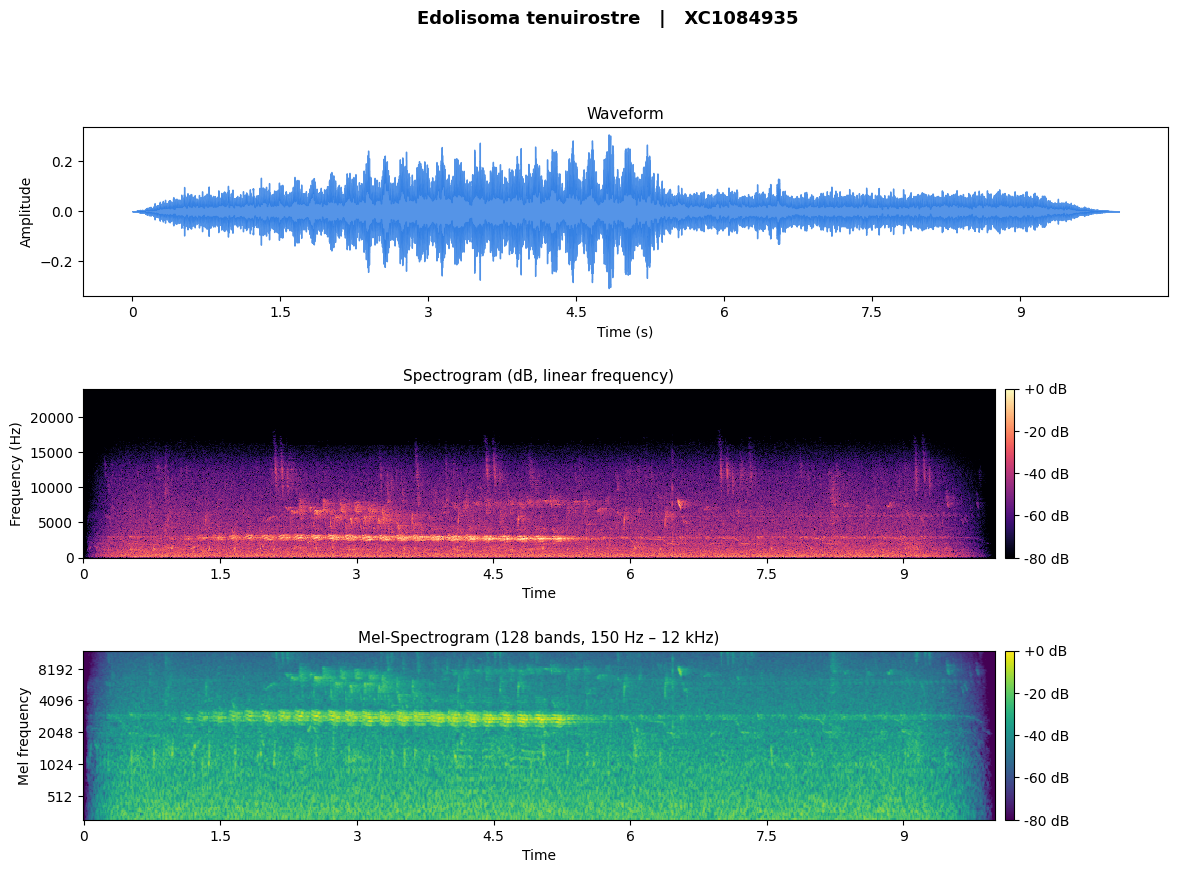

  Saved → XC1084935_visualisation.png

Melithreptus albogularis  —  XC1086697


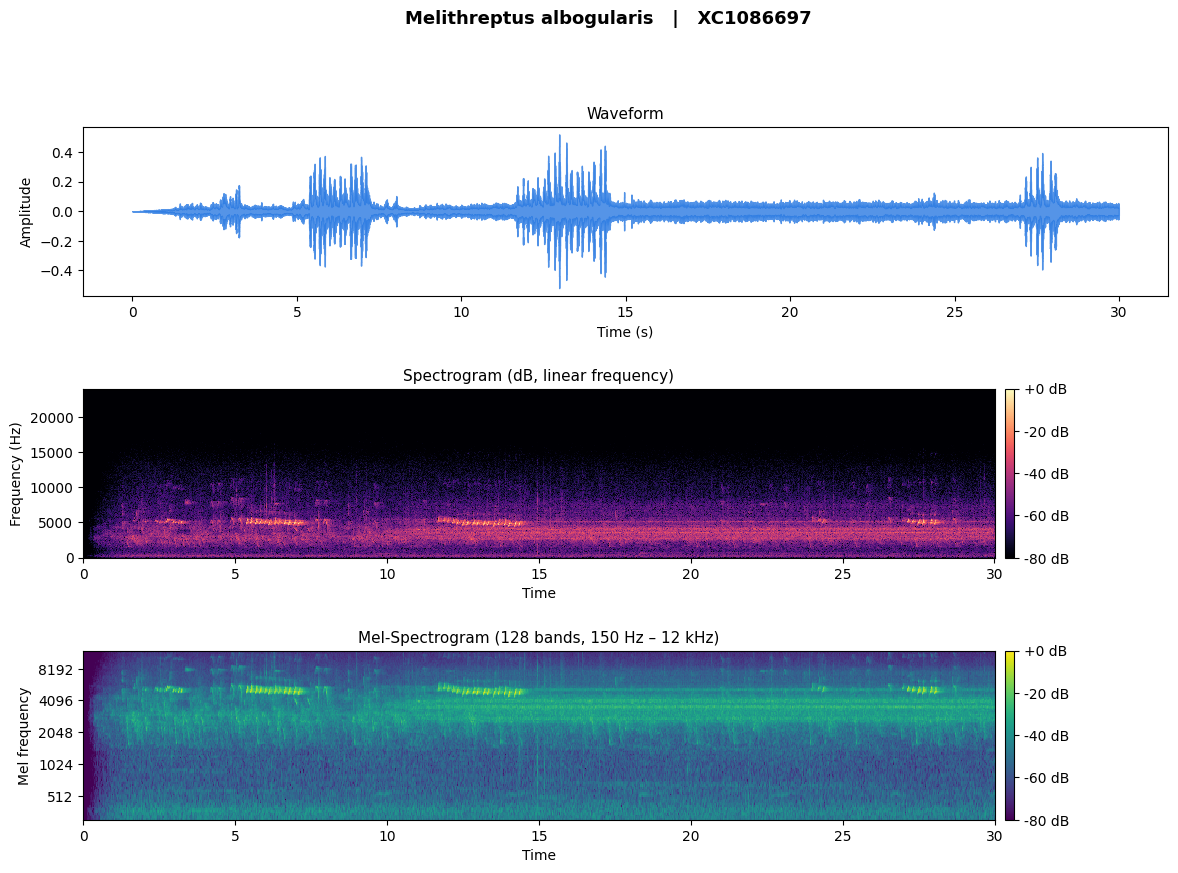

  Saved → XC1086697_visualisation.png


In [10]:
# ── Visualise one recording per species ──────────────────────────────
for sp in valid_df["species"].unique():
    sample = valid_df[valid_df["species"] == sp].iloc[0]
    print(f"\n{sp}  —  {sample['recording_id']}")
    plot_recording(
        audio_path   = sample["audio_path"],
        species      = sp,
        recording_id = sample["recording_id"],
    )

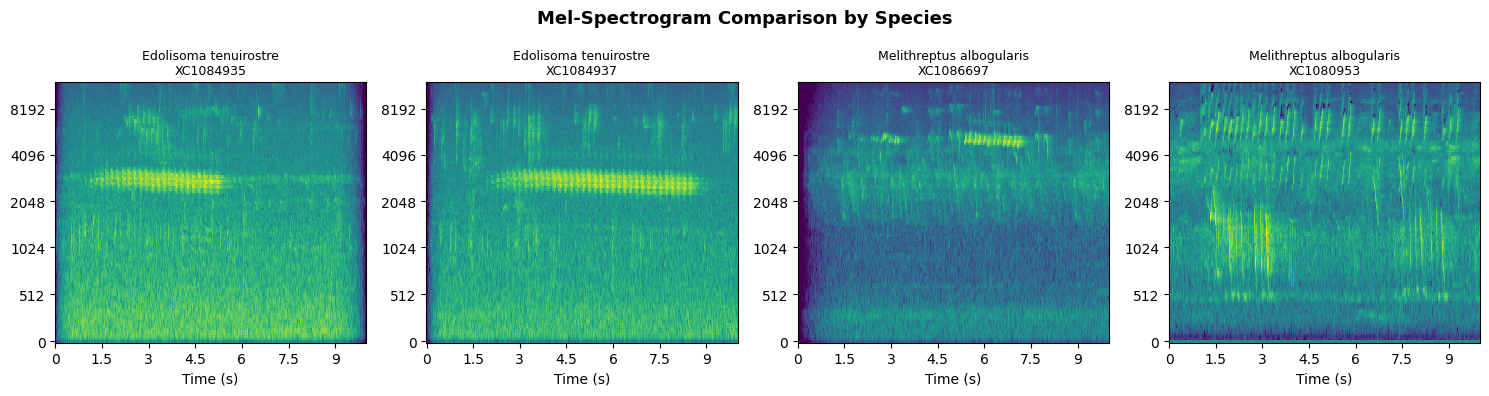

Saved → species_comparison.png


In [11]:
def plot_species_comparison(df, n_per_species=2, figsize=(15, 4)):
    """
    Side-by-side mel-spectrograms for quick inter-species comparison.
    Useful for spotting visual differences in call structure.
    """
    rows = []
    for sp in df["species"].unique():
        rows.append(df[df["species"] == sp].head(n_per_species))
    subset = pd.concat(rows).reset_index(drop=True)

    n = len(subset)
    fig, axes = plt.subplots(1, n, figsize=(figsize[0], figsize[1]))
    if n == 1:
        axes = [axes]

    fig.suptitle("Mel-Spectrogram Comparison by Species", fontsize=13, fontweight="bold")

    for ax, (_, row) in zip(axes, subset.iterrows()):
        y, sr = librosa.load(str(row["audio_path"]), sr=None, mono=True, duration=10)
        M     = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=12000)
        M_db  = librosa.power_to_db(M, ref=np.max)
        librosa.display.specshow(M_db, sr=sr, x_axis="time", y_axis="mel",
                                 fmax=12000, ax=ax, cmap="viridis")
        sp_short = " ".join(row["species"].split()[:2])
        ax.set_title(f"{sp_short}\n{row['recording_id']}", fontsize=9)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("")

    plt.tight_layout()
    out = RESULTS_DIR / "species_comparison.png"
    plt.savefig(out, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved → {out.name}")


plot_species_comparison(valid_df, n_per_species=2)

---
## Section 4 — Sound Classification with BirdNET 🧠

We use **BirdNET-Analyzer** — a CNN pre-trained on 6,000+ bird species worldwide, including Australian species.  
It was developed by the K. Lisa Yang Center for Conservation Bioacoustics at Cornell Lab of Ornithology.

### How BirdNET works
1. Splits the audio into **3-second overlapping windows**
2. Converts each window to a **mel-spectrogram** (same as what we plotted above)
3. Runs a **CNN** to score each of 6,000+ species
4. Returns detections above a confidence threshold

### Location & date improve accuracy
BirdNET can filter results to only species known to occur at the recording's **lat/lon** and **time of year**.  
We pass these from our GBIF metadata automatically.

> **Python wrapper:** [`birdnetlib`](https://github.com/joeweiss/birdnetlib) — lightweight, no Java required.  
> **Paper:** Kahl et al. 2021, *Ecological Informatics* — https://doi.org/10.1016/j.ecoinf.2021.101236

In [12]:
pip install librosa soundfile resampy matplotlib pandas requests numpy birdnetlib tensorflow

Note: you may need to restart the kernel to use updated packages.


In [13]:
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer

# Load model once (slow first time — downloads weights ~50 MB)
print("Loading BirdNET model...")
analyzer = Analyzer()
print("Model ready.")


def classify_recording(row, analyzer, min_conf=0.25):
    """
    Run BirdNET on a single recording.

    Returns a list of detection dicts, each with:
      recording_id, known_species, lat, lon, date,
      detected_species, detected_common,
      confidence, start_time_s, end_time_s
    """
    path = row.get("audio_path")
    if path is None or not Path(path).exists():
        return []

    # Parse date for seasonal range filtering
    date = None
    if row.get("date"):
        try:
            date = datetime.strptime(str(row["date"])[:10], "%Y-%m-%d")
        except ValueError:
            pass

    try:
        rec = Recording(
            analyzer,
            str(path),
            lat      = row.get("lat"),
            lon      = row.get("lon"),
            date     = date,
            min_conf = min_conf,
        )
        rec.analyze()
    except Exception as e:
        print(f"  [error] {row['recording_id']}: {e}")
        return []

    detections = []
    for det in rec.detections:
        detections.append({
            "recording_id"    : row["recording_id"],
            "known_species"   : row["species"],
            "lat"             : row.get("lat"),
            "lon"             : row.get("lon"),
            "date"            : row.get("date"),
            "detected_species": det["scientific_name"],
            "detected_common" : det["common_name"],
            "confidence"      : round(det["confidence"], 3),
            "start_time_s"    : det["start_time"],
            "end_time_s"      : det["end_time"],
        })
    return detections

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/pydub/utils.py:170: RuntimeWarning: Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work
  warn("Couldn't find ffmpeg or avconv - defaulting to ffmpeg, but may not work", RuntimeWarning)


Loading BirdNET model...
Labels loaded.
load model True
Model loaded.
Labels loaded.
load_species_list_model
Meta model loaded.
Model ready.


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [14]:
print(f"Classifying {len(valid_df)} recordings with BirdNET...\n")

all_detections = []
for _, row in valid_df.iterrows():
    dets = classify_recording(row, analyzer, min_conf=MIN_CONFIDENCE)
    print(f"  {row['recording_id']}  ({row['species']})  →  {len(dets)} detection(s)")
    all_detections.extend(dets)

detections_df = pd.DataFrame(all_detections)

print(f"\nTotal detections: {len(detections_df)}")
if len(detections_df):
    detections_df.to_csv(RESULTS_DIR / "detections.csv", index=False)
    print(f"Saved → {RESULTS_DIR / 'detections.csv'}")

detections_df.head(20)

Classifying 10 recordings with BirdNET...

read_audio_data


read_audio_data: complete, read  3 chunks.
analyze_recording XC1084935.mp3
recording has lon/lat
set_predicted_species_list_from_position
return_predicted_species_list
7
246 species loaded.
  XC1084935  (Edolisoma tenuirostre)  →  1 detection(s)
read_audio_data
read_audio_data: complete, read  4 chunks.
analyze_recording XC1084937.mp3
recording has lon/lat
set_predicted_species_list_from_position
  XC1084937  (Edolisoma tenuirostre)  →  2 detection(s)
read_audio_data
read_audio_data: complete, read  25 chunks.
analyze_recording XC1084936.mp3
recording has lon/lat
set_predicted_species_list_from_position
  XC1084936  (Edolisoma tenuirostre)  →  27 detection(s)
read_audio_data
read_audio_data: complete, read  8 chunks.
analyze_recording XC1084934.mp3
recording has lon/lat
set_predicted_species_list_from_position
  XC1084934  (Edolisoma tenuirostre)  →  3 detection(s)
read_audio_data
read_audio_data: complete, read  8 chunks.
analyze_recording XC1088936.mp3
recording has lon/lat
set_predi

,recording_id,known_species,lat,lon,date,detected_species,detected_common,confidence,start_time_s,end_time_s
0,XC1084935,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Edolisoma tenuirostre,Common Cicadabird,0.986,3.0,6.0
1,XC1084937,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Edolisoma tenuirostre,Common Cicadabird,0.998,3.0,6.0
2,XC1084937,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Edolisoma tenuirostre,Common Cicadabird,0.817,6.0,9.0
3,XC1084936,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Edolisoma tenuirostre,Common Cicadabird,0.673,0.0,3.0
4,XC1084936,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Pachycephala rufiventris,Rufous Whistler,0.325,0.0,3.0
5,XC1084936,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Edolisoma tenuirostre,Common Cicadabird,0.276,6.0,9.0
6,XC1084936,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Edolisoma tenuirostre,Common Cicadabird,0.832,9.0,12.0
7,XC1084936,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Edolisoma tenuirostre,Common Cicadabird,0.847,12.0,15.0
8,XC1084936,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Edolisoma tenuirostre,Common Cicadabird,0.902,15.0,18.0
9,XC1084936,Edolisoma tenuirostre,-28.846,152.0499,2026-02-21,Colluricincla harmonica,Gray Shrikethrush,0.553,15.0,18.0


Top detected species (all recordings combined):


,detected_species,detected_common,n_detections,mean_conf,max_conf
6,Melithreptus albogularis,White-throated Honeyeater,31,0.733,0.996
4,Edolisoma tenuirostre,Common Cicadabird,23,0.715,0.998
2,Cormobates leucophaea,White-throated Treecreeper,7,0.409,0.503
5,Malurus melanocephalus,Red-backed Fairywren,3,0.367,0.392
1,Colluricincla harmonica,Gray Shrikethrush,2,0.505,0.553
8,Oriolus flavocinctus,Green Oriole,2,0.366,0.424
12,Ptiloris magnificus,Magnificent Riflebird,2,0.524,0.758
0,Acanthiza lineata,Striated Thornbill,1,0.300,0.300
3,Corvus coronoides,Australian Raven,1,0.734,0.734
7,Menura novaehollandiae,Superb Lyrebird,1,0.388,0.388


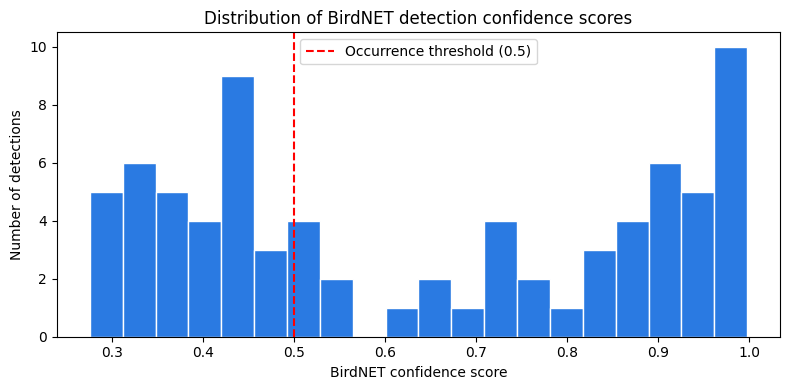

In [15]:
if len(detections_df) > 0:
    # Summary: top detected species
    summary = (
        detections_df
        .groupby(["detected_species", "detected_common"])
        .agg(
            n_detections = ("confidence", "count"),
            mean_conf    = ("confidence", "mean"),
            max_conf     = ("confidence", "max"),
        )
        .reset_index()
        .sort_values("n_detections", ascending=False)
    )
    summary["mean_conf"] = summary["mean_conf"].round(3)
    summary["max_conf"]  = summary["max_conf"].round(3)
    print("Top detected species (all recordings combined):")
    display(summary.head(15))

    # Confidence distribution plot
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(detections_df["confidence"], bins=20, color="#2a7ae2", edgecolor="white")
    ax.axvline(OCCURRENCE_CONFIDENCE, color="red", linestyle="--",
               label=f"Occurrence threshold ({OCCURRENCE_CONFIDENCE})")
    ax.set_xlabel("BirdNET confidence score")
    ax.set_ylabel("Number of detections")
    ax.set_title("Distribution of BirdNET detection confidence scores")
    ax.legend()
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "confidence_distribution.png", dpi=150)
    plt.show()

---
## Section 5 — Species Occurrence Export 📍

We treat each unique **species × location** combination detected above the confidence threshold as a **presence record** (occurrence = 1).  
This mirrors the structure of occurrence data in databases like ALA, GBIF, and iNaturalist.

**Output CSV columns:**

| Column | Description |
|--------|-------------|
| `species` | Scientific name (from BirdNET) |
| `common_name` | English common name |
| `lat` | Decimal latitude of the recording location |
| `lon` | Decimal longitude |
| `date` | Recording date |
| `confidence` | Highest BirdNET confidence at this location |
| `n_detections` | Number of 3-s windows where species was detected |

> **Note on false positives:** BirdNET can mis-identify species, especially at confidence < 0.5.  
> The `OCCURRENCE_CONFIDENCE` threshold (set in Section 0) controls the trade-off.

In [16]:
def build_occurrence_records(detections_df, min_conf=0.50):
    """
    Collapse BirdNET detections into species-occurrence records.

    Each row = one species detected at one lat/lon = 1 occurrence.
    Duplicates within the same recording are merged (keeping max confidence).

    Parameters
    ----------
    detections_df : DataFrame from classify_recording()
    min_conf      : minimum BirdNET confidence to include

    Returns
    -------
    pd.DataFrame with columns: species, common_name, lat, lon, date,
                                confidence, n_detections
    """
    if detections_df.empty:
        print("No detections to export.")
        return pd.DataFrame()

    occ = (
        detections_df
        .query("confidence >= @min_conf and lat == lat and lon == lon")  # drop NaN lat/lon
        .groupby(["detected_species", "detected_common", "lat", "lon", "date"])
        .agg(
            confidence   = ("confidence", "max"),
            n_detections = ("confidence", "count"),
        )
        .reset_index()
        .rename(columns={
            "detected_species" : "species",
            "detected_common"  : "common_name",
        })
        .sort_values(["species", "lat", "lon"])
        .reset_index(drop=True)
    )
    occ["confidence"] = occ["confidence"].round(3)
    return occ


occ_df = build_occurrence_records(detections_df, min_conf=OCCURRENCE_CONFIDENCE)

if not occ_df.empty:
    # Core export: species, lat, lon
    core_cols = ["species", "lat", "lon"]
    occ_df[core_cols].to_csv(RESULTS_DIR / "species_occurrences.csv", index=False)

    # Full export with all metadata
    occ_df.to_csv(RESULTS_DIR / "species_occurrences_full.csv", index=False)

    print(f"Exported {len(occ_df)} occurrence records")
    print(f"  Core  (species, lat, lon)      → {RESULTS_DIR / 'species_occurrences.csv'}")
    print(f"  Full  (with date, confidence)  → {RESULTS_DIR / 'species_occurrences_full.csv'}")

occ_df

Exported 12 occurrence records
  Core  (species, lat, lon)      → results/species_occurrences.csv
  Full  (with date, confidence)  → results/species_occurrences_full.csv


,species,common_name,lat,lon,date,confidence,n_detections
0,Colluricincla harmonica,Gray Shrikethrush,-28.8460,152.0499,2026-02-21,0.553,1
1,Cormobates leucophaea,White-throated Treecreeper,-28.8460,152.0499,2026-02-21,0.503,1
2,Corvus coronoides,Australian Raven,-28.8460,152.0499,2026-02-21,0.734,1
3,Edolisoma tenuirostre,Common Cicadabird,-28.8460,152.0499,2026-02-21,0.998,13
4,Edolisoma tenuirostre,Common Cicadabird,-28.2004,153.1893,2025-02-23,0.913,2
5,Melithreptus albogularis,White-throated Honeyeater,-29.6266,153.2959,2026-02-20,0.996,12
6,Melithreptus albogularis,White-throated Honeyeater,-28.2307,153.1359,2025-10-26,0.865,4
7,Melithreptus albogularis,White-throated Honeyeater,-27.8038,153.4284,2024-09-24,0.994,4
8,Melithreptus albogularis,White-throated Honeyeater,-12.4422,130.9102,2023-08-04,0.688,3
9,Pardalotus punctatus,Spotted Pardalote,-28.8460,152.0499,2026-02-21,0.514,1


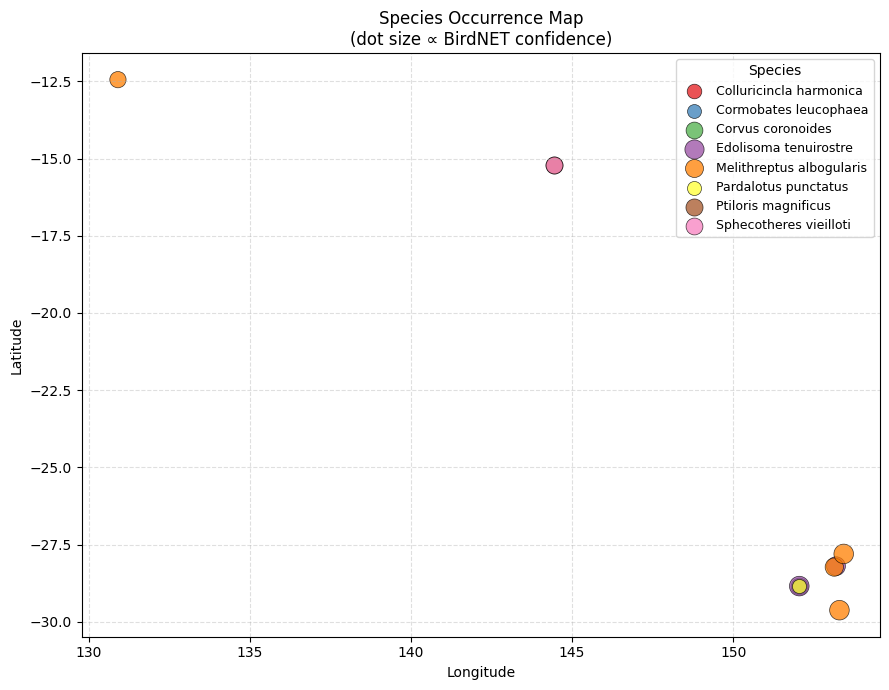

Saved → results/occurrence_map.png


In [17]:
# ── Quick map of occurrence points ──────────────────────────────────
if not occ_df.empty and occ_df[["lat", "lon"]].notna().all(axis=None):
    fig, ax = plt.subplots(figsize=(9, 7))

    species_list = occ_df["species"].unique()
    colours      = plt.cm.Set1(np.linspace(0, 0.8, len(species_list)))
    colour_map   = dict(zip(species_list, colours))

    for sp, grp in occ_df.groupby("species"):
        ax.scatter(
            grp["lon"], grp["lat"],
            c     = [colour_map[sp]],
            label = sp,
            s     = grp["confidence"] * 200,  # size = confidence
            alpha = 0.75,
            edgecolors = "k",
            linewidths = 0.5,
        )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title("Species Occurrence Map\n(dot size ∝ BirdNET confidence)", fontsize=12)
    ax.legend(title="Species", fontsize=9, title_fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "occurrence_map.png", dpi=150)
    plt.show()
    print(f"Saved → {RESULTS_DIR / 'occurrence_map.png'}")

---
## Summary of Outputs

All outputs are written to the `results/` folder:

| File | Description |
|------|-------------|
| `metadata.csv` | Recording metadata with lat/lon, URLs, local paths |
| `quality_checks.csv` | Per-file QC report (duration, SNR, flags) |
| `detections.csv` | All BirdNET detections (all windows, all species) |
| `species_occurrences.csv` | **Core output** — species, lat, lon (ready for ALA/GBIF upload) |
| `species_occurrences_full.csv` | As above + date, confidence, n_detections |
| `*_visualisation.png` | Waveform + spectrogram + mel-spectrogram per recording |
| `species_comparison.png` | Side-by-side mel-spectrogram comparison |
| `confidence_distribution.png` | Histogram of BirdNET confidence scores |
| `occurrence_map.png` | Map of detected species locations |

---
## Swap your data

To run this same workflow on your own recordings (e.g. from an Acoustic Observatory or AudioMoth):

1. Set `DATA_SOURCE = "local"` in **Section 0**
2. Point `LOCAL_AUDIO_DIR` to your WAV folder
3. Provide a `metadata.csv` with columns:  
   `recording_id, species, common_name, lat, lon, audio_path, date`
4. Re-run all cells — everything from Section 2 onward runs identically.

---
*Notebook authored for the EcoCommons / QCIF acoustic modelling workshop.*  
*Data: Xeno-canto via GBIF (CC BY-NC-SA 4.0). Classifier: BirdNET (Cornell Lab, MIT License).*  
*Reference: [AgaMiko/bird-recognition-review](https://github.com/AgaMiko/bird-recognition-review) · [BirdSet](https://huggingface.co/datasets/DBD-research-group/BirdSet)*
